# PRÁCTICA PSO

In [2]:
#Importamos los datos del excel
import pandas as pd
data = pd.read_excel('Datos_PSO.xlsx')

#Separamos en variables (x) y (y)
x = data['x'].to_numpy()
y = data['y'].to_numpy()


🔹 Mínimo encontrado:
A = 2.5057
B = 1.5007
C = 0.5115
ECM mínimo = 0.090914


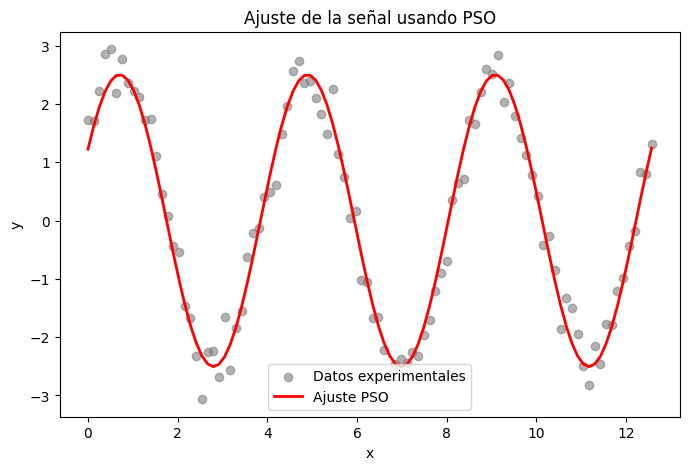

In [3]:
import numpy as np
# ------------------- Funciones ------------------

# Función objetivo: calcula el error cuadrático medio
def funcion_objetivo(parametros):
    A, B, C = parametros
    y_pred = A * np.sin(B * x + C)
    error = np.mean((y - y_pred) ** 2)  # ECM
    return error


# Inicialización de partículas
def inicializar_particulas(n_particulas, dim, limites):
    posiciones = np.zeros((n_particulas, dim))
    velocidades = np.zeros((n_particulas, dim))

    l_inf = np.array([limites[i][0] for i in range(dim)])
    l_sup = np.array([limites[i][1] for i in range(dim)])

    for i in range(n_particulas):
        for d in range(dim):
            posiciones[i][d] = np.random.uniform(l_inf[d], l_sup[d])
            velocidades[i][d] = np.random.uniform(-abs(l_sup[d]-l_inf[d]), abs(l_sup[d]-l_inf[d])) * 0.1

    return posiciones, velocidades


# ------------------- PSO -------------------
dim = 3  # A, B, C
n_particulas = 100
max_iter = 1000
w = 0.7
c1 = 1.5
c2 = 1.5

# Límites de búsqueda para A, B y C (ajústalos si conoces el rango de tu señal)
limites = [(0, 10), (0, 10), (-np.pi, np.pi)]

# Inicialización
posiciones, velocidades = inicializar_particulas(n_particulas, dim, limites)
pbest_posicion = np.copy(posiciones)
pbest_valores = np.zeros(n_particulas)

for i in range(n_particulas):
    pbest_valores[i] = funcion_objetivo(posiciones[i])

gbest_indice = np.argmin(pbest_valores)
gbest_posicion = np.copy(pbest_posicion[gbest_indice])
gbest_valor = np.copy(pbest_valores[gbest_indice])

# Límite de velocidad
v_max = np.zeros(dim)
for d in range(dim):
    v_max[d] = 0.2 * (limites[d][1] - limites[d][0])

# Bucle principal del PSO
for t in range(max_iter):
    for i in range(n_particulas):
        r1 = np.random.random(dim)
        r2 = np.random.random(dim)

        # Actualizar velocidad y posición
        velocidades[i] = (
            w * velocidades[i]
            + c1 * r1 * (pbest_posicion[i] - posiciones[i])
            + c2 * r2 * (gbest_posicion - posiciones[i])
        )

        # Limitar velocidad
        velocidades[i] = np.clip(velocidades[i], -v_max, v_max)

        # Actualizar posición
        posiciones[i] += velocidades[i]

        # Evaluar nueva posición
        fitness = funcion_objetivo(posiciones[i])

        # Actualizar pbest y gbest
        if fitness < pbest_valores[i]:
            pbest_valores[i] = fitness
            pbest_posicion[i] = np.copy(posiciones[i])

        if fitness < gbest_valor:
            gbest_valor = fitness
            gbest_posicion = np.copy(posiciones[i])

print("🔹 Mínimo encontrado:")
print(f"A = {gbest_posicion[0]:.4f}")
print(f"B = {gbest_posicion[1]:.4f}")
print(f"C = {gbest_posicion[2]:.4f}")
print(f"ECM mínimo = {gbest_valor:.6f}")

# %%
# Visualizamos el ajuste
import matplotlib.pyplot as plt

y_ajuste = gbest_posicion[0] * np.sin(gbest_posicion[1] * x + gbest_posicion[2])

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='gray', alpha=0.6, label='Datos experimentales')
plt.plot(x, y_ajuste, color='red', linewidth=2, label='Ajuste PSO')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Ajuste de la señal usando PSO')
plt.show()
